# Module 3 — Portfolio Construction

Exploratory notebook for `analysis/portfolio.py`. Given a target allocation
and the adjusted-close prices from Module 1, simulate a lump-sum investment
and track portfolio value over time.

**Key concepts:** NumPy weighted operations (`np.dot`-style broadcasting),
`pandas` alignment, scalar vs array operations.

> Convention (see `SPEC.md`): explore here first, then refactor the working
> logic into `analysis/portfolio.py`. This notebook is kept as an honest
> artifact of the process.

## Setup

In [1]:
import sys
from pathlib import Path

# Make the project root importable when running from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import fetch, portfolio
from analysis.config import DEFAULT_TICKERS, DEFAULT_WEIGHTS, DEFAULT_START, DEFAULT_INVESTMENT

# Pull from the local cache written by Module 1 (network only on a miss).
prices = fetch.load_or_fetch(DEFAULT_TICKERS, DEFAULT_START)
prices.tail()

Ticker,VTI,VXUS,BND
Date,,,
2026-07-28,365.989990,83.250000,72.386574
2026-07-29,360.420013,82.389999,72.127472
2026-07-30,366.269989,84.769997,72.167336
2026-07-31,368.209991,84.589996,71.978004
2026-08-03,373.839996,85.019997,72.150002


## 1. Build the portfolio

Allocate `$10,000` across `VTI` / `VXUS` / `BND` at the 60/30/10 target
weights. Each ticker's dollar allocation is converted to a share count at its
first available price, then revalued daily by broadcasting `shares * prices`
— no rebalancing happens here, so the mix drifts with the market on its own.

In [2]:
portfolio.validate_weights(DEFAULT_WEIGHTS)  # raises if the weights don't sum to 1.0

built = portfolio.build_portfolio(prices, DEFAULT_WEIGHTS, DEFAULT_INVESTMENT)
built.tail()

Ticker,VTI,VXUS,BND,total
Date,,,,
2026-07-28,36705.758306,7781.178690,1277.223778,45764.160774
2026-07-29,36147.135863,7700.796487,1272.652059,45120.584409
2026-07-30,36733.839860,7923.249146,1273.355431,45930.444437
2026-07-31,36928.406003,7906.424948,1270.014782,46104.845732
2026-08-03,37493.048763,7946.616049,1273.049582,46712.714394


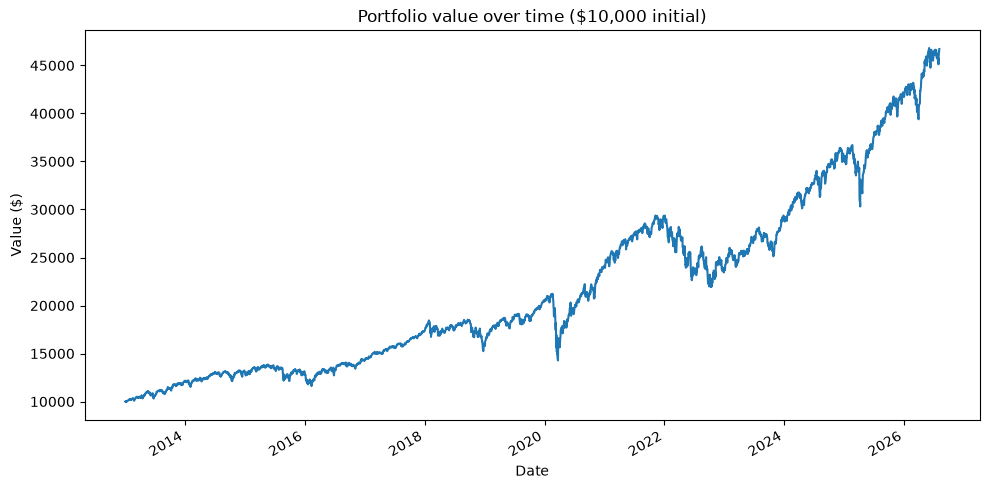

In [3]:
built["total"].plot(figsize=(10, 5), title="Portfolio value over time ($10,000 initial)")
plt.ylabel("Value ($)")
plt.tight_layout()

## 2. Allocation drift — pie chart at start vs end

No rebalancing means winners grow to a larger share of the portfolio over
time. Compare the actual weights on day one to the weights today.

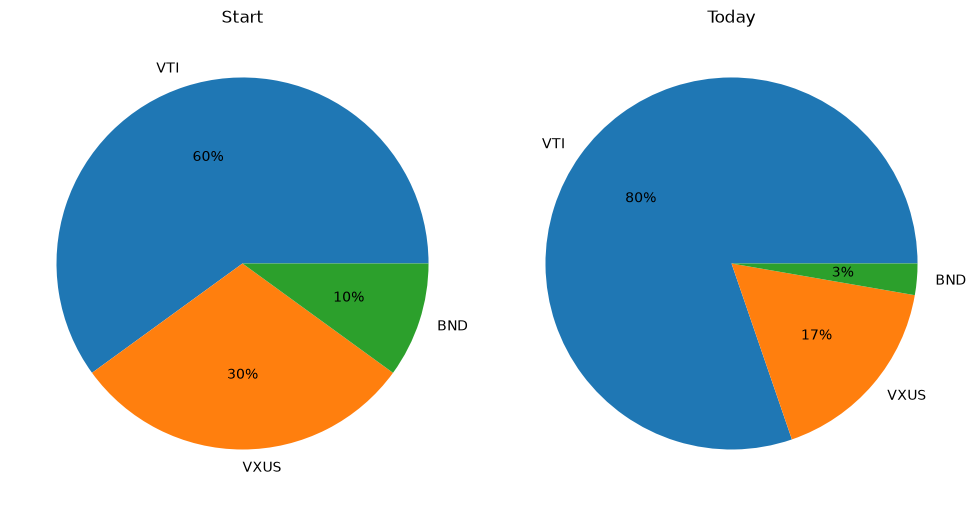

In [4]:
tickers = list(DEFAULT_WEIGHTS.keys())
start_weights = built[tickers].iloc[0] / built["total"].iloc[0]
end_weights = built[tickers].iloc[-1] / built["total"].iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
start_weights.plot.pie(ax=axes[0], autopct="%1.0f%%", title="Start")
end_weights.plot.pie(ax=axes[1], autopct="%1.0f%%", title="Today")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()

## 3. Diversification benefit — vs. 100% VTI

How does the 60/30/10 mix compare to putting the whole $10,000 into `VTI`
alone?

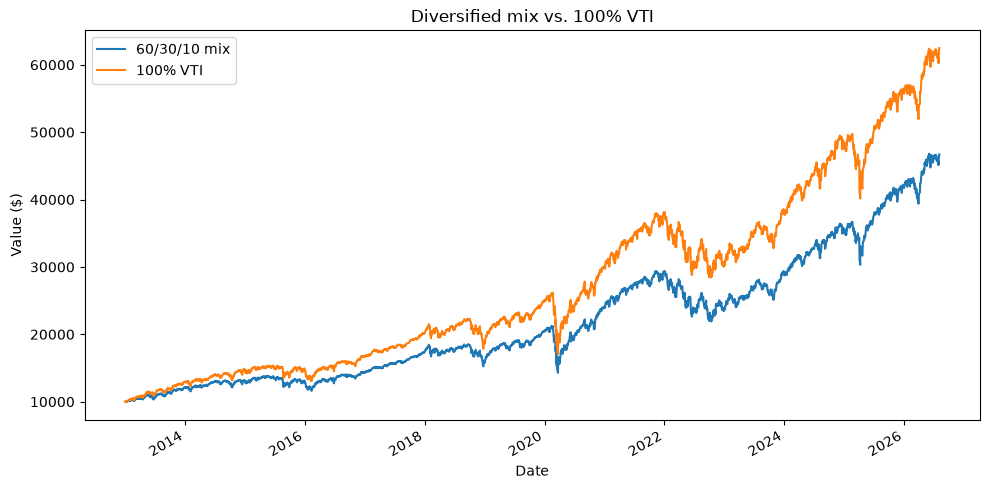

In [5]:
all_vti = portfolio.build_portfolio(prices, {"VTI": 1.0}, DEFAULT_INVESTMENT)

comparison = pd.DataFrame({
    "60/30/10 mix": built["total"],
    "100% VTI": all_vti["total"],
})
comparison.plot(figsize=(10, 5), title="Diversified mix vs. 100% VTI")
plt.ylabel("Value ($)")
plt.tight_layout()

In [6]:
terminal = comparison.iloc[-1]
terminal.map(lambda x: f"${x:,.2f}")

60/30/10 mix    $46,712.71
100% VTI        $62,488.41
Name: 2026-08-03 00:00:00, dtype: object

## 4. Max drawdown — worst peak-to-trough decline

`max_drawdown` compares every point in time to the running peak seen so far.
The minimum of that series is the worst decline an investor who bought at the
top would have experienced before recovery.

In [7]:
mix_dd = portfolio.max_drawdown(built["total"])
vti_dd = portfolio.max_drawdown(all_vti["total"])
print(f"60/30/10 mix max drawdown: {mix_dd:.2%}")
print(f"100% VTI max drawdown:     {vti_dd:.2%}")

60/30/10 mix max drawdown: -32.71%
100% VTI max drawdown:     -35.00%


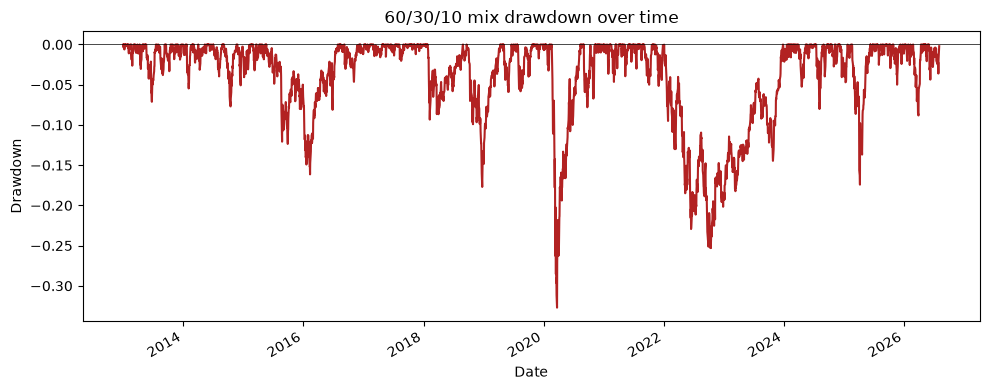

In [8]:
running_max = built["total"].cummax()
drawdown = (built["total"] - running_max) / running_max
drawdown.plot(figsize=(10, 4), title="60/30/10 mix drawdown over time", color="firebrick")
plt.ylabel("Drawdown")
plt.axhline(0, color="black", lw=0.5)
plt.tight_layout()

In [9]:
worst_day = drawdown.idxmin()
print(f"Worst drawdown of {drawdown.min():.2%} occurred on {worst_day.date()}")

Worst drawdown of -32.71% occurred on 2020-03-23


## Checkpoint

**What does NumPy broadcasting mean, and where did you use it?**

Broadcasting lets an operation between arrays of different shapes apply
element-wise without writing an explicit loop, by "stretching" the smaller
shape to match. `build_portfolio` uses it twice: dividing a `Series` of dollar
allocations by a `Series` of first prices (both indexed by ticker) to get
share counts, and then multiplying the full `prices` DataFrame by that
per-ticker `shares` Series — pandas aligns on the column axis and broadcasts
each ticker's scalar share count down its entire price column. The result is
a full value-over-time table with no explicit iteration over rows or tickers.